## Food Delivery Operations & Timing Analysis

## Food Delivery Operations & Timing Analysis - END-TO-END Project

Project Objective:

 - The objective of this project is to analyze food delivery order data using Python and understand patterns in ordering, delivery timing, pricing, payments, discounts and platform economics.
 - This project focuses on applying Python concepts to a real-world dataset, including data handling, functions, OOP, iterators, generators, exception handling, Pandas, NumPy and visualization.
 - The analysis will be used to derive meaningful business insights from the data.

In [3]:
# Import our libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the data
df = pd.read_csv("Downloads/food_orders.csv")

In [7]:
df.describe()

,Order ID,Order Value,Delivery Fee,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,1053.969000,28.620000,126.99000,29.832000,28.300000
std,288.819436,530.975339,16.958278,43.06405,11.627165,49.614228
min,1.000000,104.000000,0.000000,50.00000,10.000000,0.000000
25%,250.750000,597.750000,20.000000,90.00000,20.000000,0.000000
50%,500.500000,1038.500000,30.000000,127.00000,30.000000,0.000000
75%,750.250000,1494.000000,40.000000,164.00000,40.000000,50.000000
max,1000.000000,1995.000000,50.000000,200.00000,50.000000,150.000000


In [13]:
df.shape

(1000, 12)

In [15]:
df.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks'],
      dtype='object')

## Step 1 - Business understanding

### We wants to understand: How efficiently are orders being delivered, when demand is highest and how order activity affects the platform's financial performance?

#### Delivery Performance

In [27]:
# Q1. How long does an order take to get delivered?
# Convert date/time columns to datetime
df["Order Date and Time"] = pd.to_datetime(df["Order Date and Time"])
df["Delivery Date and Time"] = pd.to_datetime(df["Delivery Date and Time"])
# Calculate delivery time in minutes
df["Delivery Time (Minutes)"] = (df["Delivery Date and Time"] - df["Order Date and Time"]).dt.total_seconds() / 60
# Summary
df["Delivery Time (Minutes)"].describe()

count    1000.000000
mean       73.575000
std        26.015133
min        30.000000
25%        50.000000
50%        74.000000
75%        96.000000
max       119.000000
Name: Delivery Time (Minutes), dtype: float64

In [29]:
# Q2. What does the typical delivery time look like?
# mean and median:
print("Average Delivery Time:",
      round(df["Delivery Time (Minutes)"].mean(), 2), "minutes")
print("Median Delivery Time:",
      round(df["Delivery Time (Minutes)"].median(), 2), "minutes")

Average Delivery Time: 73.58 minutes
Median Delivery Time: 74.0 minutes


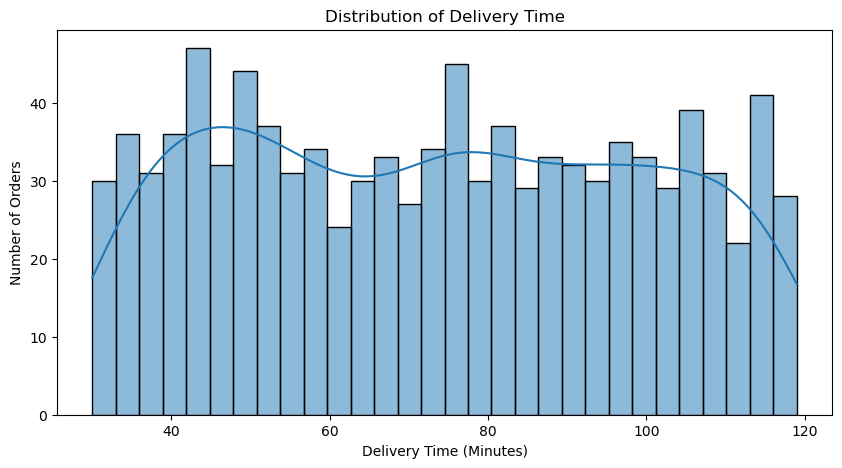

In [31]:
# visualize the distribution:
plt.figure(figsize=(10, 5))
sns.histplot(
    df["Delivery Time (Minutes)"],
    bins=30,
    kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")
plt.show()

In [33]:
# Q3. Are there unusually slow deliveries?
Q1 = df["Delivery Time (Minutes)"].quantile(0.25)
Q3 = df["Delivery Time (Minutes)"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
print("Upper Limit:", round(upper_limit, 2), "minutes")

Upper Limit: 165.0 minutes


In [35]:
# Finding the unusually slow deliveries:
slow_deliveries = df[
    df["Delivery Time (Minutes)"] > upper_limit]
print("Number of unusually slow deliveries:",
      len(slow_deliveries))

Number of unusually slow deliveries: 0


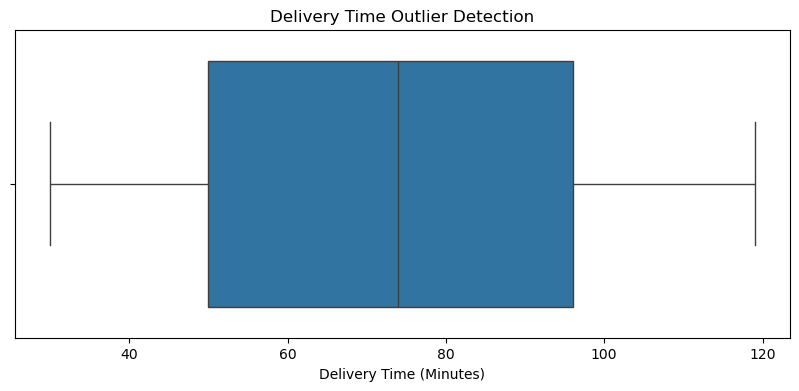

In [39]:
# Visualize this:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Delivery Time (Minutes)"])
plt.title("Delivery Time Outlier Detection")
plt.xlabel("Delivery Time (Minutes)")
plt.show()

In [41]:
# Q4. Does delivery time vary depending on when the order is placed?
# First extract the hour:
df["Order Hour"] = df["Order Date and Time"].dt.hour
# Calculate delivery time by order hour:
hourly_delivery = (
    df.groupby("Order Hour")["Delivery Time (Minutes)"]
      .agg(["mean", "median", "count"])
      .reset_index())
hourly_delivery

,Order Hour,mean,median,count
0,0,75.457143,71.0,35
1,1,76.228571,82.0,35
2,2,74.052632,75.5,38
3,3,68.720930,69.0,43
4,4,75.680851,74.0,47
5,5,72.354167,69.0,48
6,6,67.041667,67.5,48
7,7,72.818182,71.0,44
8,8,72.282609,73.5,46
9,9,69.377778,62.0,45


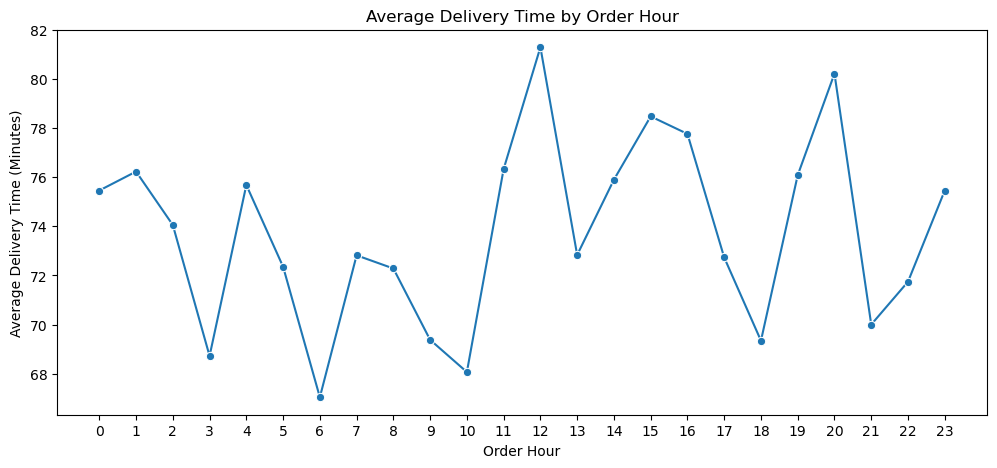

In [43]:
# Visualize this:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hourly_delivery,
    x="Order Hour",
    y="mean",
    marker="o")
plt.title("Average Delivery Time by Order Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(range(24))
plt.show()

#### Order Performance

In [46]:
# Q5. When are customers ordering most?
# Extract order hour
df["Order Hour"] = df["Order Date and Time"].dt.hour
# Find the most popular ordering hours:
order_by_hour = (
    df["Order Hour"]
    .value_counts()
    .sort_index())
order_by_hour

Order Hour
0     35
1     35
2     38
3     43
4     47
5     48
6     48
7     44
8     46
9     45
10    45
11    39
12    31
13    36
14    39
15    40
16    42
17    52
18    35
19    49
20    37
21    37
22    43
23    46
Name: count, dtype: int64

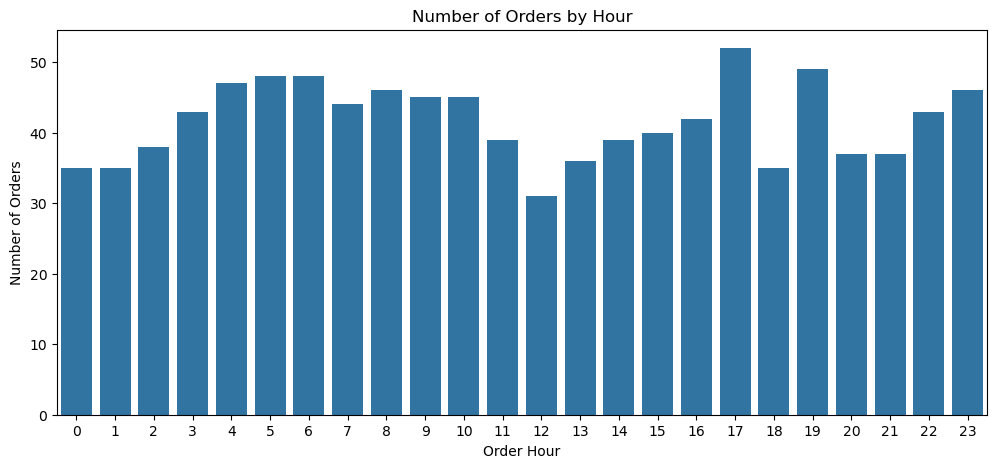

In [48]:
# Visualize this:
plt.figure(figsize=(12, 5))
sns.barplot(
    x=order_by_hour.index,
    y=order_by_hour.values)
plt.title("Number of Orders by Hour")
plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")
plt.show()

In [52]:
# Also checking which days customers order most
df["Order Day"] = df["Order Date and Time"].dt.day_name()
order_by_day = df["Order Day"].value_counts()
order_by_day

Order Day
Tuesday      172
Saturday     157
Monday       146
Wednesday    144
Thursday     133
Friday       126
Sunday       122
Name: count, dtype: int64

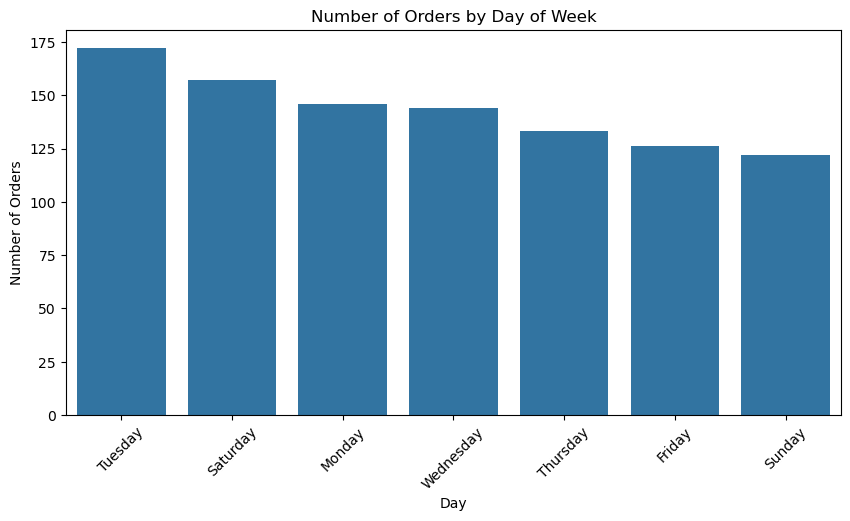

In [54]:
# Visualize this:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=order_by_day.index,
    y=order_by_day.values)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [56]:
# Q6. What is the typical order value?
df["Order Value"].describe()
print("Average Order Value:",
      round(df["Order Value"].mean(), 2))
print("Median Order Value:",
      round(df["Order Value"].median(), 2))

Average Order Value: 1053.97
Median Order Value: 1038.5


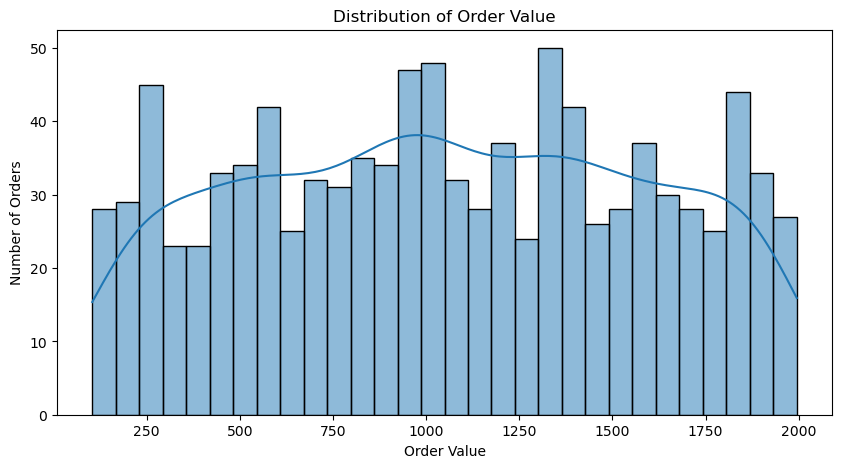

In [58]:
# Distribution:
plt.figure(figsize=(10, 5))
sns.histplot(
    df["Order Value"],
    bins=30,
    kde=True)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.show()

In [60]:
# Q7. Which payment methods are most common?
payment_counts = df["Payment Method"].value_counts()
payment_counts

Payment Method
Cash on Delivery    357
Credit Card         337
Digital Wallet      306
Name: count, dtype: int64

In [64]:
# Also we can see the percentage share:
payment_percentage = (
    df["Payment Method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))
payment_percentage

Payment Method
Cash on Delivery    35.7
Credit Card         33.7
Digital Wallet      30.6
Name: proportion, dtype: float64

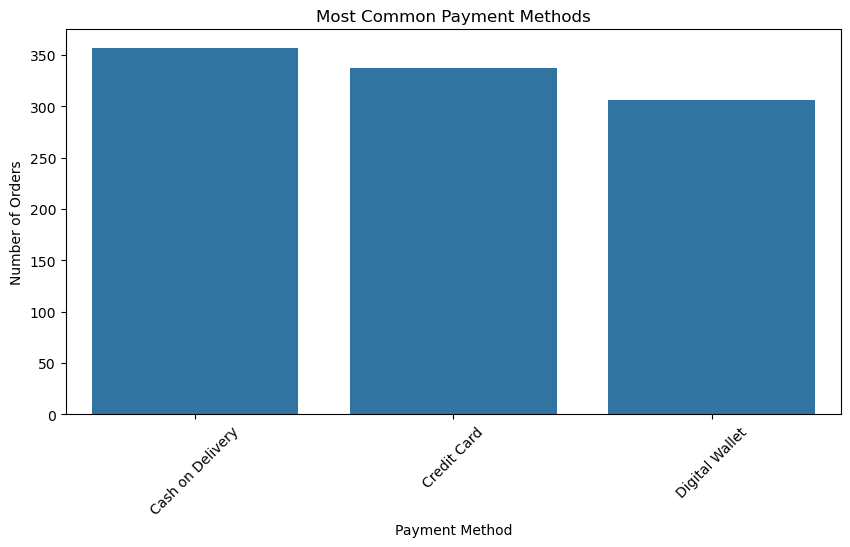

In [62]:
# Visualize this:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values)
plt.title("Most Common Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [72]:
# Q8. How frequently are discounts used?
discount_usage = df["Discounts and Offers"].notna().value_counts()
discount_usage

Discounts and Offers
True     815
False    185
Name: count, dtype: int64

In [74]:
discounted_orders = df["Discounts and Offers"].notna().sum()
non_discounted_orders = df["Discounts and Offers"].isna().sum()
print("Orders with discounts/offers:", discounted_orders)
print("Orders without discounts/offers:", non_discounted_orders)

Orders with discounts/offers: 815
Orders without discounts/offers: 185


In [78]:
# Calculate percentage
discount_percentage = (discounted_orders / len(df)) * 100
print(
    "Percentage of orders using discounts/offers:",
    round(discount_percentage, 2),
    "%")

Percentage of orders using discounts/offers: 81.5 %


In [94]:
# Which offers are used most?
offer_counts = df["Discounts and Offers"].value_counts()
offer_counts

Discounts and Offers
10%             233
50 off Promo    201
15% New User    198
5% on App       183
Name: count, dtype: int64

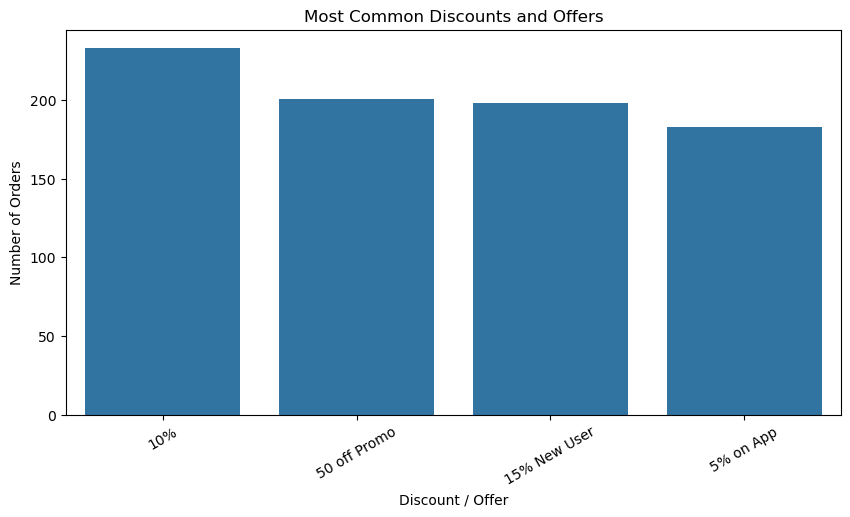

In [96]:
# Visualize this:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=offer_counts.index,
    y=offer_counts.values)
plt.title("Most Common Discounts and Offers")
plt.xlabel("Discount / Offer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

#### Platform Economics

In [99]:
# Complete summary of all 5 metrics
platform_economics = df[[
        "Order Value",
        "Delivery Fee",
        "Commission Fee",
        "Payment Processing Fee",
        "Refunds/Chargebacks"]].describe().T
platform_economics

,count,mean,std,min,25%,50%,75%,max
Order Value,1000.0,1053.969,530.975339,104.0,597.75,1038.5,1494.0,1995.0
Delivery Fee,1000.0,28.620,16.958278,0.0,20.00,30.0,40.0,50.0
Commission Fee,1000.0,126.990,43.064050,50.0,90.00,127.0,164.0,200.0
Payment Processing Fee,1000.0,29.832,11.627165,10.0,20.00,30.0,40.0,50.0
Refunds/Chargebacks,1000.0,28.300,49.614228,0.0,0.00,0.0,50.0,150.0


In [101]:
# Compare the average values
platform_economics_mean = df[[
        "Order Value",
        "Delivery Fee",
        "Commission Fee",
        "Payment Processing Fee",
        "Refunds/Chargebacks"]
].mean().sort_values(ascending=False)
platform_economics_mean

Order Value               1053.969
Commission Fee             126.990
Payment Processing Fee      29.832
Delivery Fee                28.620
Refunds/Chargebacks         28.300
dtype: float64

##### One clean comparison graph for: 
Order Value | Delivery Fee | Commission Fee | Payment Processing Fee | Refunds/Chargebacks

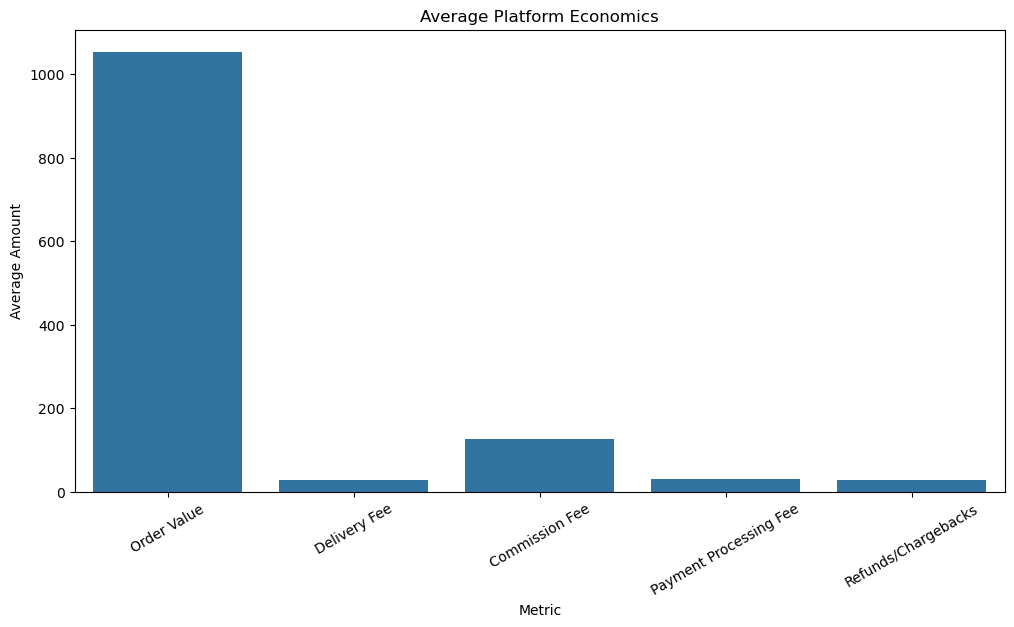

In [104]:
# Average value of each platform economic metric
platform_means = df[[
        "Order Value",
        "Delivery Fee",
        "Commission Fee",
        "Payment Processing Fee",
        "Refunds/Chargebacks"]].mean()
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x=platform_means.index,
    y=platform_means.values)
plt.title("Average Platform Economics")
plt.xlabel("Metric")
plt.ylabel("Average Amount")
plt.xticks(rotation=30)
plt.show()

In [106]:
# Financial measures
financial_summary = pd.Series({
    "Total Order Value": df["Order Value"].sum(),
    "Total Delivery Fees": df["Delivery Fee"].sum(),
    "Total Commission": df["Commission Fee"].sum(),
    "Total Payment Processing Fees": df["Payment Processing Fee"].sum(),
    "Total Refunds/Chargebacks": df["Refunds/Chargebacks"].sum(),
    "Average Order Value": df["Order Value"].mean(),
    "Average Delivery Fee": df["Delivery Fee"].mean(),
    "Average Commission": df["Commission Fee"].mean(),
    "Average Processing Fee": df["Payment Processing Fee"].mean(),
    "Average Refund/Chargeback": df["Refunds/Chargebacks"].mean()})
financial_summary

Total Order Value                1053969.000
Total Delivery Fees                28620.000
Total Commission                  126990.000
Total Payment Processing Fees      29832.000
Total Refunds/Chargebacks          28300.000
Average Order Value                 1053.969
Average Delivery Fee                  28.620
Average Commission                   126.990
Average Processing Fee                29.832
Average Refund/Chargeback             28.300
dtype: float64

In [108]:
net_platform_revenue = (
    df["Commission Fee"].sum()
    + df["Delivery Fee"].sum()
    - df["Payment Processing Fee"].sum()
    - df["Refunds/Chargebacks"].sum())
print("Net Platform Revenue:", round(net_platform_revenue, 2))

Net Platform Revenue: 97478


#### Discounts & Offers

In [111]:
# Create discount groups
df["Discount Group"] = df["Discounts and Offers"].notna().map({
    True: "With Discount/Offer",
    False: "Without Discount/Offer"})
discount_comparison = (
    df.groupby("Discount Group")
      .agg(
          Orders=("Order ID", "count"),
          Average_Order_Value=("Order Value", "mean"),
          Average_Delivery_Fee=("Delivery Fee", "mean"),
          Average_Commission=("Commission Fee", "mean"),
          Average_Refund=("Refunds/Chargebacks", "mean")).round(2))
discount_comparison

,Orders,Average_Order_Value,Average_Delivery_Fee,Average_Commission,Average_Refund
Discount Group,,,,,
With Discount/Offer,815,1055.35,28.36,127.36,27.06
Without Discount/Offer,185,1047.88,29.78,125.36,33.78


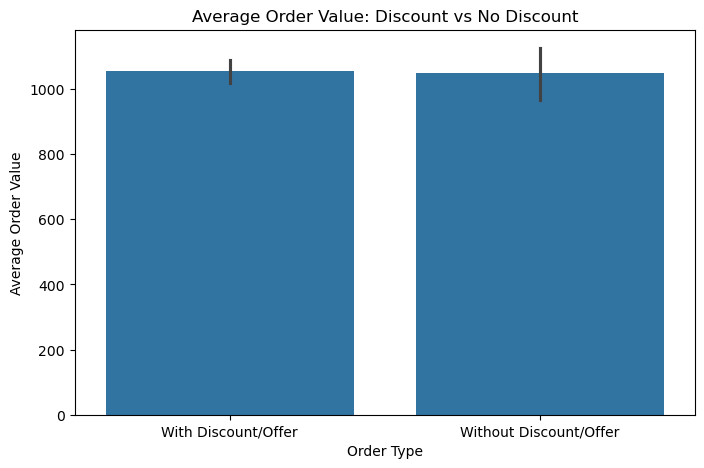

In [113]:
# Compare average order value
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Discount Group",
    y="Order Value")
plt.title("Average Order Value: Discount vs No Discount")
plt.xlabel("Order Type")
plt.ylabel("Average Order Value")
plt.show()

### Data Cleaning
Before analyzing the dataset, we need to check and improve itsdata quality.

In this stage, we will check: Missing values, Duplicate records, Data types, Invalid or unexpected values

In [116]:
df.isnull().sum()

Order ID                     0
Customer ID                  0
Restaurant ID                0
Order Date and Time          0
Delivery Date and Time       0
Order Value                  0
Delivery Fee                 0
Payment Method               0
Discounts and Offers       185
Commission Fee               0
Payment Processing Fee       0
Refunds/Chargebacks          0
Delivery Time (Minutes)      0
Order Hour                   0
Order Day                    0
Discount Group               0
dtype: int64

In [118]:
df["Discounts and Offers"].value_counts(dropna=False)

Discounts and Offers
10%             233
50 off Promo    201
15% New User    198
NaN             185
5% on App       183
Name: count, dtype: int64

In [122]:
df[df["Discounts and Offers"].isna()][
    ["Order ID", "Order Value", "Delivery Fee", "Payment Method"]]

,Order ID,Order Value,Delivery Fee,Payment Method
3,4,1463,50,Cash on Delivery
12,13,674,0,Cash on Delivery
14,15,1193,0,Credit Card
22,23,1243,40,Digital Wallet
30,31,1822,0,Digital Wallet
...,...,...,...,...
942,943,1248,20,Cash on Delivery
973,974,707,50,Digital Wallet
982,983,934,20,Digital Wallet
996,997,1627,50,Cash on Delivery


#### Missing Values — Discounts and Offers

 - The Discounts and Offers column contains 185 missing values.
 - After inspecting the affected records, the corresponding orders  still contain valid information such as Order ID, Order Value, Delivery Fee and Payment Method.
 - Since the dataset does not provide enough evidence to determine  whether a missing value means "No Discount" or "Information Not Recorded", the missing values will be retained rather than arbitrarily replaced.

In [127]:
# Cleaning check
df.duplicated().sum()

0

#### Duplicate Records
 - The dataset contains 0 duplicate rows. Therefore, no duplicate records were removed during the cleaning process.

In [130]:
df.dtypes

Order ID                            int64
Customer ID                        object
Restaurant ID                      object
Order Date and Time        datetime64[ns]
Delivery Date and Time     datetime64[ns]
Order Value                         int64
Delivery Fee                        int64
Payment Method                     object
Discounts and Offers               object
Commission Fee                      int64
Payment Processing Fee              int64
Refunds/Chargebacks                 int64
Delivery Time (Minutes)           float64
Order Hour                          int32
Order Day                          object
Discount Group                     object
dtype: object

### Data Types
 - The dataset contains appropriate data types for the current analysis.
 - The order and delivery timestamps are stored as datetime values,  while financial variables are stored as numerical values and categorical variables are stored as object/string values.
 - No immediate data-type correction is required at this stage.

In [138]:
df[["Order Value", "Delivery Fee", "Commission Fee",
    "Payment Processing Fee", "Refunds/Chargebacks",
    "Delivery Time (Minutes)"]].min()

Order Value                104.0
Delivery Fee                 0.0
Commission Fee              50.0
Payment Processing Fee      10.0
Refunds/Chargebacks          0.0
Delivery Time (Minutes)     30.0
dtype: float64

In [164]:
df.describe()

,Order ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Commission Fee,Payment Processing Fee,Refunds/Chargebacks,Delivery Time (Minutes),Order Hour
count,1000.000000,1000,1000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2024-01-20 11:03:07.648000,2024-01-20 12:16:42.148000256,1053.969000,28.620000,126.99000,29.832000,28.300000,73.575000,11.540000
min,1.000000,2024-01-01 02:12:47,2024-01-01 03:59:47,104.000000,0.000000,50.00000,10.000000,0.000000,30.000000,0.000000
25%,250.750000,2024-01-11 18:45:27.249999872,2024-01-11 19:54:57.249999872,597.750000,20.000000,90.00000,20.000000,0.000000,50.000000,6.000000
50%,500.500000,2024-01-20 11:38:43,2024-01-20 13:02:23,1038.500000,30.000000,127.00000,30.000000,0.000000,74.000000,11.000000
75%,750.250000,2024-01-30 03:47:34.249999872,2024-01-30 05:09:34.249999872,1494.000000,40.000000,164.00000,40.000000,50.000000,96.000000,17.000000
max,1000.000000,2024-02-07 23:56:12,2024-02-08 01:45:12,1995.000000,50.000000,200.00000,50.000000,150.000000,119.000000,23.000000
std,288.819436,NaN,NaN,530.975339,16.958278,43.06405,11.627165,49.614228,26.015133,6.881697


### Data Transformation

Data transformation converts raw data into formats that are easier
to analyze.

In this stage, we will:
- Convert date and time columns into datetime format
- Extract useful date and time components
- Prepare the dataset for feature engineering and analysis

In [170]:
# Convert date/time columns into datetime format
df["Order Date and Time"] = pd.to_datetime(
    df["Order Date and Time"],
    errors="coerce")
df["Delivery Date and Time"] = pd.to_datetime(
    df["Delivery Date and Time"],
    errors="coerce")
df[["Order Date and Time", "Delivery Date and Time"]]

,Order Date and Time,Delivery Date and Time
0,2024-02-01 01:11:52,2024-02-01 02:39:52
1,2024-02-02 22:11:04,2024-02-02 22:46:04
2,2024-01-31 05:54:35,2024-01-31 06:52:35
3,2024-01-16 22:52:49,2024-01-16 23:38:49
4,2024-01-29 01:19:30,2024-01-29 02:48:30
...,...,...
995,2024-01-14 05:57:00,2024-01-14 06:39:00
996,2024-01-28 08:50:43,2024-01-28 10:10:43
997,2024-01-21 09:43:19,2024-01-21 10:44:19
998,2024-01-30 22:23:38,2024-01-31 00:07:38


#### Date-Time Transformation

The order and delivery timestamp columns were converted in o
datetime format to enable time-based analysis.

The transformation was successful, with all 1,000 records retained.

In [173]:
df["Order Hour"] = df["Order Date and Time"].dt.hour
df["Order Day"] = df["Order Date and Time"].dt.day_name()
df["Order Month"] = df["Order Date and Time"].dt.month_name()
df[[
    "Order Date and Time",
    "Order Hour",
    "Order Day",
    "Order Month"]]

,Order Date and Time,Order Hour,Order Day,Order Month
0,2024-02-01 01:11:52,1,Thursday,February
1,2024-02-02 22:11:04,22,Friday,February
2,2024-01-31 05:54:35,5,Wednesday,January
3,2024-01-16 22:52:49,22,Tuesday,January
4,2024-01-29 01:19:30,1,Monday,January
...,...,...,...,...
995,2024-01-14 05:57:00,5,Sunday,January
996,2024-01-28 08:50:43,8,Sunday,January
997,2024-01-21 09:43:19,9,Sunday,January
998,2024-01-30 22:23:38,22,Tuesday,January


# Stage 4. Feature Engineering

Feature engineering involves creating new meaningful variables from existing data.

For this project, the engineered features will help measure delivery performance, order behavior, discount usage and platform economics.

In [180]:
# Feature 1 — Delivery Time
df["Delivery Time (Minutes)"] = (
    df["Delivery Date and Time"] -
    df["Order Date and Time"]
).dt.total_seconds() / 60
df[[
    "Order Date and Time",
    "Delivery Date and Time",
    "Delivery Time (Minutes)"
]]

,Order Date and Time,Delivery Date and Time,Delivery Time (Minutes)
0,2024-02-01 01:11:52,2024-02-01 02:39:52,88.0
1,2024-02-02 22:11:04,2024-02-02 22:46:04,35.0
2,2024-01-31 05:54:35,2024-01-31 06:52:35,58.0
3,2024-01-16 22:52:49,2024-01-16 23:38:49,46.0
4,2024-01-29 01:19:30,2024-01-29 02:48:30,89.0
...,...,...,...
995,2024-01-14 05:57:00,2024-01-14 06:39:00,42.0
996,2024-01-28 08:50:43,2024-01-28 10:10:43,80.0
997,2024-01-21 09:43:19,2024-01-21 10:44:19,61.0
998,2024-01-30 22:23:38,2024-01-31 00:07:38,104.0


In [189]:
# Feature 2 - Discount Status: Classifying each order as Discount Applied or No Discount based on the recorded offer information.
df["Discount Status"] = df["Discounts and Offers"].fillna("No Discount").apply(
    lambda x: "Discount Applied" if x != "No Discount" else "No Discount")
df[["Discounts and Offers", "Discount Status"]]

,Discounts and Offers,Discount Status
0,5% on App,Discount Applied
1,10%,Discount Applied
2,15% New User,Discount Applied
3,NaN,No Discount
4,50 off Promo,Discount Applied
...,...,...
995,5% on App,Discount Applied
996,NaN,No Discount
997,NaN,No Discount
998,15% New User,Discount Applied


In [191]:
# Feature 3 — Total Customer Spend: Total Customer Spend combines the food order value and delivery fee to represent the customer's total order cost.
df["Total Customer Spend"] = df["Order Value"] + df["Delivery Fee"]
df[[
    "Order Value",
    "Delivery Fee",
    "Total Customer Spend"]]

,Order Value,Delivery Fee,Total Customer Spend
0,1914,0,1914
1,986,40,1026
2,937,30,967
3,1463,50,1513
4,1992,30,2022
...,...,...,...
995,825,0,825
996,1627,50,1677
997,553,20,573
998,1414,0,1414


In [219]:
# Feature 4 — Platform Revenue: Platform Revenue combines commission and payment processing fees generated from each order.
df["Platform Fees"] = (
    df["Commission Fee"] +
    df["Payment Processing Fee"])
df[[
    "Commission Fee",
    "Payment Processing Fee",
    "Platform Fees"]]

,Commission Fee,Payment Processing Fee,Platform Fees
0,150,47,197
1,198,23,221
2,195,45,240
3,146,27,173
4,130,50,180
...,...,...,...
995,165,47,212
996,110,42,152
997,64,31,95
998,199,34,233


In [227]:
# Feature 5 - Refunds/Chargebacks: Platform fees adjusted for refunds and chargebacks.
df["Net Platform Revenue"] = (
    df["Platform Fees"] -
    df["Refunds/Chargebacks"])
df[[
    "Platform Fees",
    "Refunds/Chargebacks",
    "Net Platform Revenue"]]

,Platform Fees,Refunds/Chargebacks,Net Platform Revenue
0,197,0,197
1,221,0,221
2,240,0,240
3,173,0,173
4,180,0,180
...,...,...,...
995,212,50,162
996,152,0,152
997,95,0,95
998,233,0,233


In [225]:
# Feature 6- Order Value Category: Insight: Categorizing orders by value, making it easier to compare customer spending patterns.
df["Order Value Category"] = pd.cut(
    df["Order Value"],
    bins=[0, 500, 1000, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"])
df[["Order Value", "Order Value Category"]]

,Order Value,Order Value Category
0,1914,High Value
1,986,Medium Value
2,937,Medium Value
3,1463,High Value
4,1992,High Value
...,...,...
995,825,Medium Value
996,1627,High Value
997,553,Medium Value
998,1414,High Value


In [207]:
# Feature 7 — Delivery Performance Category: Categorizing orders by delivery speed, making it easier to compare fast, normal and slow deliveries.
df["Delivery Performance"] = pd.cut(
    df["Delivery Time (Minutes)"],
    bins=[0, 45, 75, float("inf")],
    labels=["Fast", "Normal", "Slow"])
df[[
    "Delivery Time (Minutes)",
    "Delivery Performance"]]

,Delivery Time (Minutes),Delivery Performance
0,88.0,Slow
1,35.0,Fast
2,58.0,Normal
3,46.0,Normal
4,89.0,Slow
...,...,...
995,42.0,Fast
996,80.0,Slow
997,61.0,Normal
998,104.0,Slow


In [209]:
# Feature 8 — Order Time Category: Insight: Groups orders by time of day, helping us identify when customers place the most orders.
df["Order Time Category"] = pd.cut(
    df["Order Hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"])
df[[
    "Order Hour",
    "Order Time Category"]]

,Order Hour,Order Time Category
0,1,Night
1,22,Evening
2,5,Night
3,22,Evening
4,1,Night
...,...,...
995,5,Night
996,8,Morning
997,9,Morning
998,22,Evening


In [211]:
# Feature 9 - weekday vs weekend ordering behavior
df["Day Type"] = df["Order Date and Time"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday")
df[[
    "Order Date and Time",
    "Day Type"]]

,Order Date and Time,Day Type
0,2024-02-01 01:11:52,Weekday
1,2024-02-02 22:11:04,Weekday
2,2024-01-31 05:54:35,Weekday
3,2024-01-16 22:52:49,Weekday
4,2024-01-29 01:19:30,Weekday
...,...,...
995,2024-01-14 05:57:00,Weekend
996,2024-01-28 08:50:43,Weekend
997,2024-01-21 09:43:19,Weekend
998,2024-01-30 22:23:38,Weekday


In [213]:
# Feature 10 — Refund Flag
df["Refund Flag"] = df["Refunds/Chargebacks"].apply(
    lambda x: "Refunded" if x > 0 else "No Refund")
df[[
    "Refunds/Chargebacks",
    "Refund Flag"]]

,Refunds/Chargebacks,Refund Flag
0,0,No Refund
1,0,No Refund
2,0,No Refund
3,0,No Refund
4,0,No Refund
...,...,...
995,50,Refunded
996,0,No Refund
997,0,No Refund
998,0,No Refund


In [215]:
# Feature 11 — Net Order Value
df["Net Order Value"] = (
    df["Order Value"] -
    df["Refunds/Chargebacks"])
df[[
    "Order Value",
    "Refunds/Chargebacks",
    "Net Order Value"]]

,Order Value,Refunds/Chargebacks,Net Order Value
0,1914,0,1914
1,986,0,986
2,937,0,937
3,1463,0,1463
4,1992,0,1992
...,...,...,...
995,825,50,775
996,1627,0,1627
997,553,0,553
998,1414,0,1414


## 5. EDA & Analysis

#### A. Delivery Performance

In [231]:
# Delivery Performance → Q1: What is the typical delivery time?
df["Delivery Time (Minutes)"].describe()

count    1000.000000
mean       73.575000
std        26.015133
min        30.000000
25%        50.000000
50%        74.000000
75%        96.000000
max       119.000000
Name: Delivery Time (Minutes), dtype: float64

In [233]:
print("Average Delivery Time:", df["Delivery Time (Minutes)"].mean())
print("Median Delivery Time:", df["Delivery Time (Minutes)"].median())

Average Delivery Time: 73.575
Median Delivery Time: 74.0


**Insight:** Orders take about 74 minutes to deliver on average, with delivery times ranging from 30 to 119 minutes.

In [238]:
# How does delivery performance vary by day?
delivery_by_day = (
    df.groupby("Order Day")["Delivery Time (Minutes)"]
      .agg(["count", "mean", "median"])
      .reindex([
          "Monday", "Tuesday", "Wednesday",
          "Thursday", "Friday", "Saturday", "Sunday"]))
delivery_by_day

,count,mean,median
Order Day,,,
Monday,146,74.000000,73.0
Tuesday,172,69.732558,68.0
Wednesday,144,78.284722,80.0
Thursday,133,72.368421,73.0
Friday,126,74.404762,79.0
Saturday,157,76.547771,78.0
Sunday,122,69.557377,69.0


In [240]:
delivery_by_day.sort_values("mean", ascending=False)

,count,mean,median
Order Day,,,
Wednesday,144,78.284722,80.0
Saturday,157,76.547771,78.0
Friday,126,74.404762,79.0
Monday,146,74.000000,73.0
Thursday,133,72.368421,73.0
Tuesday,172,69.732558,68.0
Sunday,122,69.557377,69.0


**Insight:** Wednesday has the highest average delivery time (78.3 min), while Sunday has the lowest (69.6 min).

In [260]:
# Which hours have the longest delivery times?
delivery_by_hour = (
    df.groupby("Order Hour")["Delivery Time (Minutes)"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False))
delivery_by_hour.head(5)

,count,mean,median
Order Hour,,,
12,31,81.290323,82.0
20,37,80.216216,79.0
15,40,78.475000,84.5
16,42,77.761905,82.0
11,39,76.333333,73.0


In [266]:
# How does delivery time vary by order time category?
delivery_by_time = (
    df.groupby("Order Time Category")["Delivery Time (Minutes)"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False))
delivery_by_time


C:\Users\SANJANA\AppData\Local\Temp\ipykernel_31696\503261433.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Order Time Category")["Delivery Time (Minutes)"]


,count,mean,median
Order Time Category,,,
Afternoon,240,76.204167,77.5
Evening,247,73.963563,75.0
Night,246,73.609756,73.0
Morning,267,70.820225,69.0


**Insight:** Afternoon orders have the highest average delivery time (76.2 min), while morning orders have the lowest (70.8 min).

#### B. Order Performance

In [274]:
# When are most orders placed?
orders_by_day = df["Order Day"].value_counts()
orders_by_day

Order Day
Tuesday      172
Saturday     157
Monday       146
Wednesday    144
Thursday     133
Friday       126
Sunday       122
Name: count, dtype: int64

In [276]:
orders_by_hour = df["Order Hour"].value_counts().sort_index()
orders_by_hour

Order Hour
0     35
1     35
2     38
3     43
4     47
5     48
6     48
7     44
8     46
9     45
10    45
11    39
12    31
13    36
14    39
15    40
16    42
17    52
18    35
19    49
20    37
21    37
22    43
23    46
Name: count, dtype: int64

**Insight:** Tuesday has the highest order volume (172 orders), while Sunday has the lowest (122 orders); 5 PM is the busiest observed hour with 52 orders.

In [283]:
# Q6. Which order time category generates the most orders?
orders_by_time = (
    df["Order Time Category"]
    .value_counts())
orders_by_time

Order Time Category
Morning      267
Evening      247
Night        246
Afternoon    240
Name: count, dtype: int64

**Insight:** Morning has the highest order volume (267 orders), while Afternoon has the lowest (240 orders).

In [286]:
# Which order-value category is most common?
df["Order Value Category"].value_counts()

Order Value Category
High Value      528
Medium Value    281
Low Value       191
Name: count, dtype: int64

**Insight:** High-value orders dominate the dataset, accounting for 528 of 1,000 orders.

#### C. Discounts & Offers

In [292]:
# Q8. How common are discounts?
df["Discount Status"].value_counts()

Discount Status
Discount Applied    815
No Discount         185
Name: count, dtype: int64

**Insight:** Discounts were applied to 815 orders (81.5%), while 185 orders received no discount.

In [294]:
# Which offers are used most?
df["Discounts and Offers"].value_counts(dropna=False)

Discounts and Offers
10%             233
50 off Promo    201
15% New User    198
NaN             185
5% on App       183
Name: count, dtype: int64

**Insight:** The 10% offer was the most common promotion (233 orders), followed by the 50 off Promo (201).

#### D. Platform Economics

In [306]:
# Q10. How much does the platform generate from fees?
df[[
    "Commission Fee",
    "Payment Processing Fee",
    "Platform Fees",
    "Refunds/Chargebacks",
    "Net Platform Revenue"
]].describe()

,Commission Fee,Payment Processing Fee,Platform Fees,Refunds/Chargebacks,Net Platform Revenue
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,126.99000,29.832000,156.822000,28.300000,128.52200
std,43.06405,11.627165,44.338631,49.614228,66.84049
min,50.00000,10.000000,62.000000,0.000000,-86.00000
25%,90.00000,20.000000,120.000000,0.000000,89.00000
50%,127.00000,30.000000,155.000000,0.000000,135.00000
75%,164.00000,40.000000,195.000000,50.000000,182.00000
max,200.00000,50.000000,250.000000,150.000000,250.00000


**Insight:** The platform generates an average of 156.82 in fees per order, while refunds/chargebacks reduce this to an average net platform revenue of 128.52.

In [308]:
# What is the total financial contribution?
print("Total Order Value:", df["Order Value"].sum())
print("Total Delivery Fees:", df["Delivery Fee"].sum())
print("Total Platform Fees:", df["Platform Fees"].sum())
print("Total Refunds/Chargebacks:", df["Refunds/Chargebacks"].sum())
print("Net Platform Revenue:", df["Net Platform Revenue"].sum())

Total Order Value: 1053969
Total Delivery Fees: 28620
Total Platform Fees: 156822
Total Refunds/Chargebacks: 28300
Net Platform Revenue: 128522


**Insight:** Across 1,000 orders, total platform fees reached 156,822, while refunds/chargebacks reduced net platform revenue to 128,522.

## Step 6. Visualization

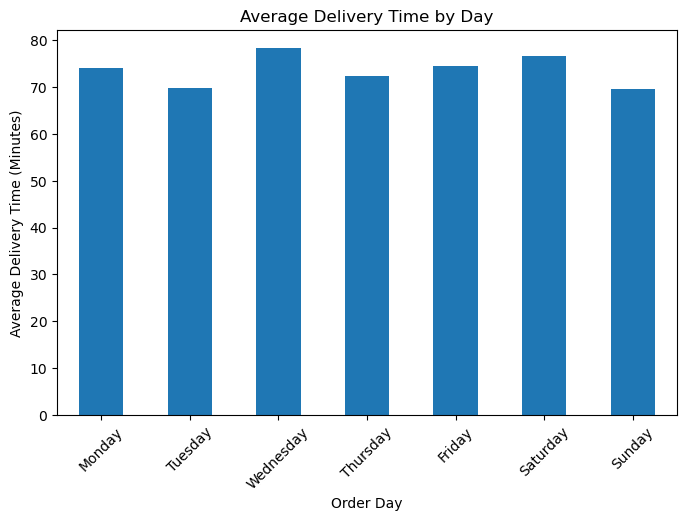

In [313]:
# Delivery Performance:
plt.figure(figsize=(8, 5))
delivery_by_day["mean"].plot(kind="bar")
plt.title("Average Delivery Time by Day")
plt.xlabel("Order Day")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(rotation=45)
plt.show()

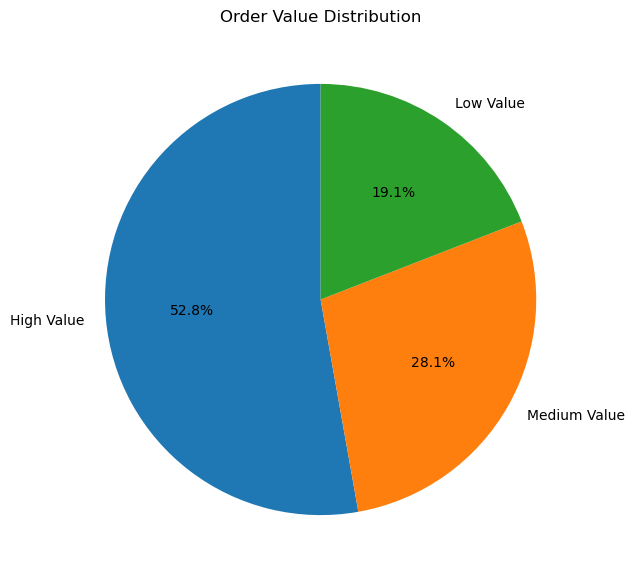

In [321]:
# Order Performance
order_value_mix = df["Order Value Category"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    order_value_mix,
    labels=order_value_mix.index,
    autopct="%1.1f%%",
    startangle=90)
plt.title("Order Value Distribution")
plt.show()

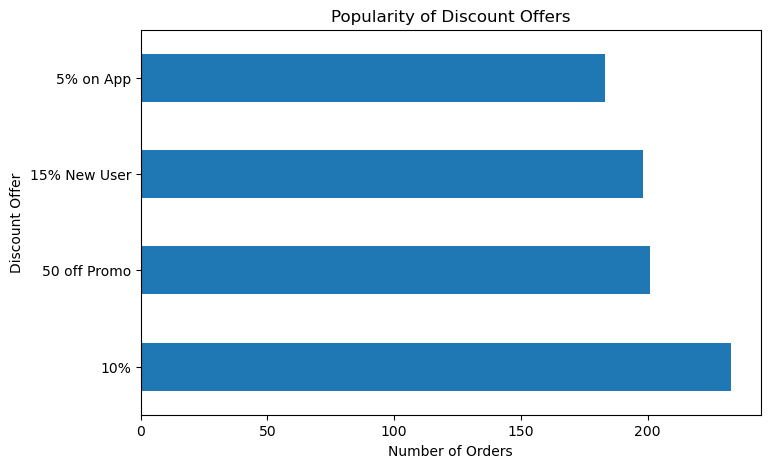

In [323]:
# Discounts & Offers
offer_counts = df["Discounts and Offers"].value_counts()
plt.figure(figsize=(8, 5))
offer_counts.plot(kind="barh")
plt.title("Popularity of Discount Offers")
plt.xlabel("Number of Orders")
plt.ylabel("Discount Offer")
plt.show()

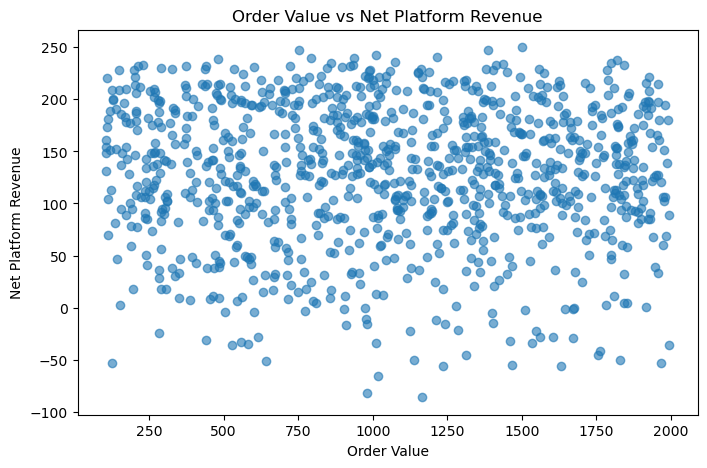

In [325]:
# Platform Economics
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Order Value"],
    df["Net Platform Revenue"],
    alpha=0.6)
plt.title("Order Value vs Net Platform Revenue")
plt.xlabel("Order Value")
plt.ylabel("Net Platform Revenue")
plt.show()

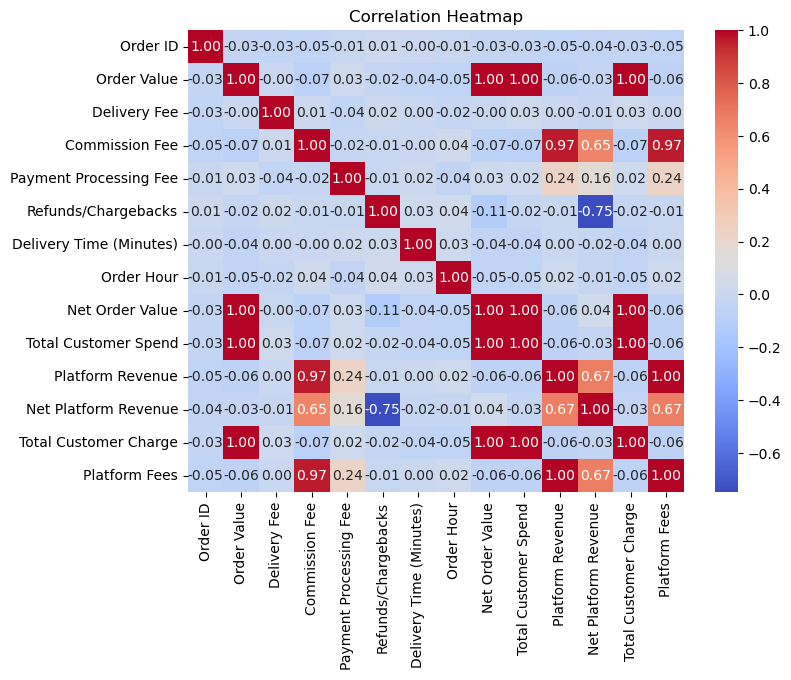

In [339]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Correlation Analysis
 - Order Value and Total Customer Charge have a very strong positive relationship: This means when the order value increases, the total amount paid by the customer also increases.
 - Commission Fee is highly related to Platform Revenue, which shows that commission is one of the main sources of income for the platform.
 - Refunds/Chargebacks have a strong negative relationship with Net Platform Revenue: This means more refunds reduce the platform's overall profit.
 - Delivery Time has very little relationship with Order Value and Revenue. This suggests that delivery delays are mostly caused by operational factors like traffic, restaurant preparation time or rider availability.
 - Most of the other numerical columns have weak correlations, showing that each factor affects the business differently and should be analyzed separately.

## 7. Findings

- The average food delivery time is around 74 minutes.
- Delivery time changes depending on the day and time of the order.
- Wednesday has the highest average delivery time, while Sunday has the lowest.
- Tuesday has the highest number of orders in the dataset.
- Most orders fall under the High Value category.
- Discounts are used in most of the orders, with the 10% offer being the most common.
- The platform generated revenue through commission and payment processing fees, while refunds and chargebacks reduced the final revenue.
- Order value and net platform revenue show a relationship that can be explored further from the visualization.

## 8. Business Recommendations

- Improve delivery operations during slower periods such as Wednesday and afternoon hours.
- Monitor high-order-volume days like Tuesday to ensure enough delivery capacity.
- Continue using discounts, but focus more on offers that are popular with customers.
- Keep track of refunds and chargebacks because they reduce the platform's net revenue.
- Study the relationship between order value and platform revenue to understand which orders contribute more to the business.

## Stage 9 — Python Implementation / Advanced Python Showcase

This section demonstrates selected Python concepts used to organize and extend the food delivery analysis, including functions, comprehension , exception handling, file handling, OOP, constructors, iteratos, and generators.

In [331]:
# Functions + Comprehensions
# Function
def calculate_average(column):
    return df[column].mean()
average_delivery = calculate_average("Delivery Time (Minutes)")
print("Average Delivery Time:", average_delivery)
# List Comprehension
financial_columns = [
    col for col in df.columns
    if "Fee" in col or "Revenue" in col]
print("Financial Columns:", financial_columns)
# Dictionary Comprehension
summary = {
    col: df[col].mean()
    for col in ["Order Value", "Delivery Fee", "Commission Fee"]}
print(summary)

Average Delivery Time: 73.575
Financial Columns: ['Delivery Fee', 'Commission Fee', 'Payment Processing Fee', 'Platform Revenue', 'Net Platform Revenue', 'Platform Fees']
{'Order Value': 1053.969, 'Delivery Fee': 28.62, 'Commission Fee': 126.99}


In [333]:
# Exception Handling + File Handling
try:
    avg_delivery = df["Delivery Time (Minutes)"].mean()
    with open("project_summary.txt", "w") as file:
        file.write(f"Average Delivery Time: {avg_delivery:.2f} minutes")
    print("Project summary saved successfully.")
except KeyError:
    print("Required column not found.")
except OSError:
    print("Unable to create the file.")

Project summary saved successfully.


In [335]:
# Oop + Constructor
class DeliveryAnalyzer:
    def __init__(self, data):
        self.data = data
    def average_delivery_time(self):
        return self.data["Delivery Time (Minutes)"].mean()
    def total_orders(self):
        return len(self.data)
analyzer = DeliveryAnalyzer(df)
print("Average Delivery Time:", analyzer.average_delivery_time())
print("Total Orders:", analyzer.total_orders())

Average Delivery Time: 73.575
Total Orders: 1000


In [337]:
# Iterator + Generator
# Iterator
order_iterator = iter(df["Order ID"])
print("First 3 Order IDs:")
for _ in range(3):
    print(next(order_iterator))
# Generator
def delivery_time_generator(data):
    for time in data["Delivery Time (Minutes)"]:
        yield time
delivery_generator = delivery_time_generator(df)
print("\nFirst 3 Delivery Times:")
for _ in range(3):
    print(next(delivery_generator))

First 3 Order IDs:
1
2
3

First 3 Delivery Times:
88.0
35.0
58.0


## Project Conclusion
 - In this project, I performed an end-to-end analysis of food delivery operations using Python.
 - I cleaned and transformed the data, created new features, analyzed delivery performance, explored platform revenue, studied customer orders and generated business insights through visualizations.
 - I also demonstrated core Python concepts such as OOP, constructors, functions, iterators, generators, exception handling and file handling.
 - This project helped me understand the complete workflow of a real-world data analysis project using Python.